# Model Validation -- Cross-Validation and Hyperparameter Tuning

In [31]:
import numpy as np
import matplotlib.pyplot as plt

## K-fold Cross-Validation in Scikit-Learn

- Simple demonstration of using a cross-validation iterator in scikit-learn

In [32]:
from sklearn.model_selection import KFold


rng = np.random.RandomState(123)

y = np.array([0, 0, 0, 0, 0, 1, 1, 1, 1, 1])
X = rng.random_sample((y.shape[0], 4))


cv = KFold(n_splits=5)

for k in cv.split(X, y):
    print(k)

(array([2, 3, 4, 5, 6, 7, 8, 9]), array([0, 1]))
(array([0, 1, 4, 5, 6, 7, 8, 9]), array([2, 3]))
(array([0, 1, 2, 3, 6, 7, 8, 9]), array([4, 5]))
(array([0, 1, 2, 3, 4, 5, 8, 9]), array([6, 7]))
(array([0, 1, 2, 3, 4, 5, 6, 7]), array([8, 9]))


- In practice, we are usually interested in shuffling the dataset, because if the data records are ordered by class label, this would result in cases where the classes are not well represented in the training and test folds

In [33]:
cv = KFold(n_splits=5, random_state=123, shuffle=True)

for k in cv.split(X, y):
    print(k)

(array([1, 2, 3, 5, 6, 7, 8, 9]), array([0, 4]))
(array([0, 1, 2, 3, 4, 6, 8, 9]), array([5, 7]))
(array([0, 1, 2, 4, 5, 6, 7, 9]), array([3, 8]))
(array([0, 2, 3, 4, 5, 7, 8, 9]), array([1, 6]))
(array([0, 1, 3, 4, 5, 6, 7, 8]), array([2, 9]))


- Note that the `KFold` iterator only provides us with the array indices; in practice, we are actually interested in the array values (feature values and class labels)

In [34]:
cv = KFold(n_splits=5, random_state=123, shuffle=True)

for train_idx, valid_idx in cv.split(X, y):
    print('train labels with shuffling', y[train_idx])

train labels with shuffling [0 0 0 1 1 1 1 1]
train labels with shuffling [0 0 0 0 0 1 1 1]
train labels with shuffling [0 0 0 0 1 1 1 1]
train labels with shuffling [0 0 0 0 1 1 1 1]
train labels with shuffling [0 0 0 0 1 1 1 1]


- As discussed in the lecture, it's important to stratify the splits (very crucial for small datasets!)

In [35]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(n_splits=5, random_state=123, shuffle=True)

for train_idx, valid_idx in cv.split(X, y):
    print('train labels', y[train_idx])

train labels [0 0 0 0 1 1 1 1]
train labels [0 0 0 0 1 1 1 1]
train labels [0 0 0 0 1 1 1 1]
train labels [0 0 0 0 1 1 1 1]
train labels [0 0 0 0 1 1 1 1]


- After the illustrations of cross-validation above, the next cell demonstrates how we can actually use the iterators provided through scikit-learn to fit and evaluate a learning algorithm

In [36]:
from sklearn.tree import DecisionTreeClassifier
from mlxtend.data import iris_data
from sklearn.model_selection import train_test_split


X, y = iris_data()
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=123, test_size=0.15, 
                                                    shuffle=True, stratify=y)



cv = StratifiedKFold(n_splits=10, random_state=123, shuffle=True)

kfold_acc = 0.
for train_idx, valid_idx in cv.split(X_train, y_train):
    clf = DecisionTreeClassifier(random_state=123, max_depth=3).fit(X_train[train_idx], y_train[train_idx])
    y_pred = clf.predict(X_train[valid_idx])
    acc = np.mean(y_pred == y_train[valid_idx])*100
    kfold_acc += acc
kfold_acc /= 10
    
clf = DecisionTreeClassifier(random_state=123, max_depth=3).fit(X_train, y_train)
y_pred = clf.predict(X_test)
test_acc = np.mean(y_pred == y_test)*100
    
print('Kfold Accuracy: %.2f%%' % kfold_acc)
print('Test Accuracy: %.2f%%' % test_acc)



Kfold Accuracy: 95.26%
Test Accuracy: 95.65%


- Usually, a more convenient way to use cross-validation through scikit-learn is to use the `cross_val_score` function (note that it performs stratifies splitting for classification by default)
- (remember to ask students about whitespaces according to pep8)

In [37]:
from sklearn.model_selection import cross_val_score


cv_acc = cross_val_score(estimator=DecisionTreeClassifier(random_state=123, max_depth=3),
                         X=X_train,
                         y=y_train,
                         cv=10,
                         n_jobs=-1)

print('Kfold Accuracy: %.2f%%' % (np.mean(cv_acc)*100))

Kfold Accuracy: 96.09%


- `cross_val_score` has unfortunately no way to specify a random seed; this is not an issue in regular use cases, but it is not useful if you want to do "repeated cross-validation"
- The next cell illustrates how we can provide our own cross-validation iterator for convenience (note that the results match or "manual" `StratifiedKFold` approach we performed earlier)

In [38]:
from sklearn.model_selection import cross_val_score


cv_acc = cross_val_score(estimator=DecisionTreeClassifier(random_state=123, max_depth=3),
                         X=X_train,
                         y=y_train,
                         cv=StratifiedKFold(n_splits=10, random_state=123, shuffle=True),
                         n_jobs=-1)

print('Kfold Accuracy: %.2f%%' % (np.mean(cv_acc)*100))

Kfold Accuracy: 95.26%


## GridSearch

- For hyperparameter tuning and model selection, `GridSearchCV` is really useful

In [39]:
from sklearn.tree import DecisionTreeClassifier
from mlxtend.data import iris_data
from sklearn.model_selection import train_test_split


X, y = iris_data()
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=123, test_size=0.15, 
                                                    shuffle=True, stratify=y)

In [40]:
from sklearn.model_selection import GridSearchCV


param_grid = [{'max_depth': [1, 2, 3, 4, 5, 6, None],
               'criterion': ['gini', 'entropy']}]

gs = GridSearchCV(estimator=DecisionTreeClassifier(random_state=123),
                  param_grid=param_grid,
                  refit=True,
                  cv=10,
                  n_jobs=None)

gs.fit(X_train, y_train)

print('Best Accuracy: %.2f%%' % (gs.best_score_*100))
print('Best Params:', gs.best_params_)

Best Accuracy: 96.09%
Best Params: {'criterion': 'gini', 'max_depth': 3}


In [41]:
for i in range(len(gs.cv_results_['mean_test_score'])):
    print(gs.cv_results_['mean_test_score'][i], gs.cv_results_['params'][i]) 

0.653846153846154 {'criterion': 'gini', 'max_depth': 1}
0.9121794871794873 {'criterion': 'gini', 'max_depth': 2}
0.9608974358974359 {'criterion': 'gini', 'max_depth': 3}
0.951923076923077 {'criterion': 'gini', 'max_depth': 4}
0.9602564102564102 {'criterion': 'gini', 'max_depth': 5}
0.9602564102564102 {'criterion': 'gini', 'max_depth': 6}
0.9602564102564102 {'criterion': 'gini', 'max_depth': None}
0.653846153846154 {'criterion': 'entropy', 'max_depth': 1}
0.9121794871794873 {'criterion': 'entropy', 'max_depth': 2}
0.9608974358974359 {'criterion': 'entropy', 'max_depth': 3}
0.9365384615384617 {'criterion': 'entropy', 'max_depth': 4}
0.9448717948717948 {'criterion': 'entropy', 'max_depth': 5}
0.9525641025641025 {'criterion': 'entropy', 'max_depth': 6}
0.9525641025641025 {'criterion': 'entropy', 'max_depth': None}


- We an summarize the results in a heatmap, but note that this only works if you have 1 or 2 hyperparameters to consider

In [42]:
import matplotlib.pyplot as plt
%matplotlib inline

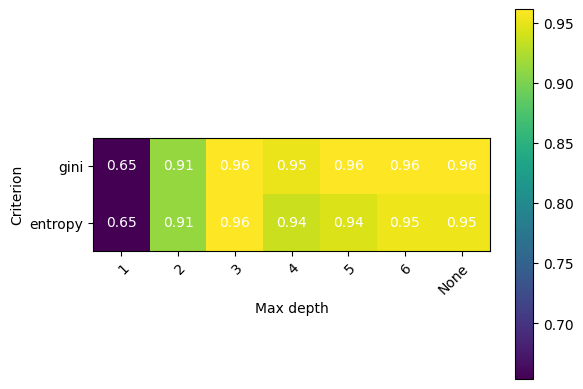

In [43]:
from mlxtend.plotting import heatmap
import numpy as np
import pandas as pd

grid = np.zeros((2, 7))
grid[0, :] = gs.cv_results_['mean_test_score'][:7]
grid[1, :] = gs.cv_results_['mean_test_score'][7:]


heatmap(grid, 
        column_names=[1, 2, 3, 4, 5, 6, "None"], 
        row_names=['gini', 'entropy'])
plt.ylabel('Criterion')
plt.xlabel('Max depth')
plt.show()

- After running `GridSearchCV`, we would fit a model with the best settings (hyperparameters on the whole training set
- By default, `GridSearchCV` already does this for us (unless, we set `refit=False`), so that we can evaluate the performance of the model on the test set

In [44]:
# gs.best_estimator_.fit(X_train, y_train)
print('Accuracy: %.2f%%' % (gs.best_estimator_.score(X_test, y_test)*100))

Accuracy: 95.65%
